In [1]:
import sys
from pathlib import Path

project_root = Path().resolve().parent
sys.path.insert(0, str(project_root))

%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from src.perceptron import Perceptron
from src.utils import plot_decision_regions

DATA_DIR = project_root / 'data'

# Тестирование — датасет пингвинов Палмера

## Загрузка и предобработка данных

Источник: https://www.kaggle.com/datasets/satyajeetrai/palmer-penguins-dataset-for-eda

In [2]:
df = pd.read_csv(DATA_DIR / 'penguins.data').dropna()
df_binary = df[(df['species'] == 'Adelie') | (df['species'] == 'Chinstrap')]

y = np.where(df_binary['species'].values == 'Adelie', -1, 1)
X = df_binary[['bill_length_mm', 'bill_depth_mm']].values

df_binary.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007


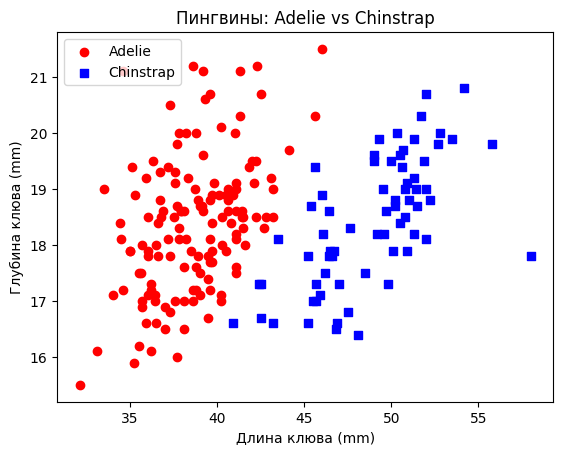

In [3]:
plt.scatter(X[y == -1, 0], X[y == -1, 1], color='red', marker='o', label='Adelie')
plt.scatter(X[y == 1, 0], X[y == 1, 1], color='blue', marker='s', label='Chinstrap')
plt.xlabel('Длина клюва (mm)')
plt.ylabel('Глубина клюва (mm)')
plt.legend(loc='upper left')
plt.title('Пингвины: Adelie vs Chinstrap')
plt.show()

### Стандартизация и проверка линейной разделимости

In [4]:
X_std = np.copy(X)
X_std[:, 0] = (X[:, 0] - X[:, 0].mean()) / X[:, 0].std()
X_std[:, 1] = (X[:, 1] - X[:, 1].mean()) / X[:, 1].std()

lr = LogisticRegression(max_iter=1000)
lr.fit(X_std, y)
print(f'Точность эталонной модели (LogisticRegression): {lr.score(X_std, y):.2%}')

Точность эталонной модели (LogisticRegression): 97.60%


## Обучение перцептрона

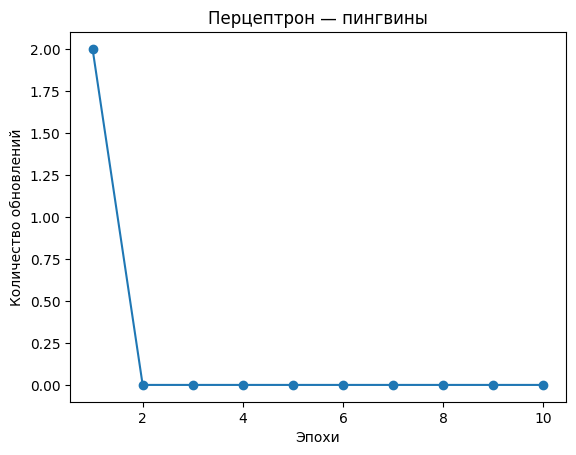

Точность перцептрона: 100.00%


In [5]:
ppn = Perceptron(eta=0.001, n_iter=10)
ppn.fit(X_std, y)

plt.plot(range(1, len(ppn.errors_) + 1), ppn.errors_, marker='o')
plt.xlabel('Эпохи')
plt.ylabel('Количество обновлений')
plt.title('Перцептрон — пингвины')
plt.show()

accuracy = (ppn.predict(X_std) == y).mean()
print(f'Точность перцептрона: {accuracy:.2%}')

## Граница решения

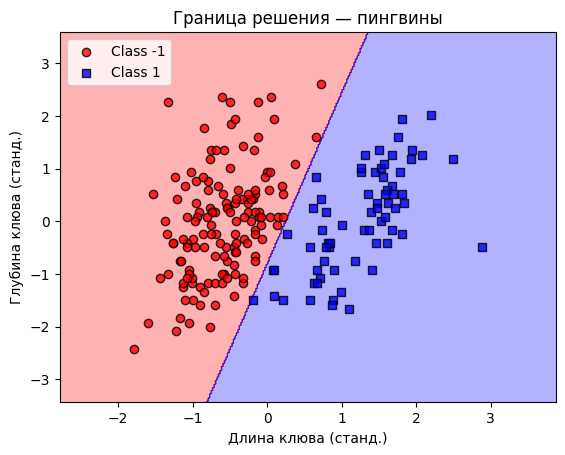

In [6]:
plot_decision_regions(X_std, y, classifier=ppn)
plt.xlabel('Длина клюва (станд.)')
plt.ylabel('Глубина клюва (станд.)')
plt.legend(loc='upper left')
plt.title('Граница решения — пингвины')
plt.show()

# Тестирование — датасет ирисов

## Загрузка и предобработка данных

In [7]:
df = pd.read_csv(DATA_DIR / 'iris.data', header=None, encoding='utf-8')
y = np.where(df.iloc[0:100, 4].values == 'Iris-setosa', -1, 1)
X = df.iloc[0:100, [0, 2]].values

df.head()

,0,1,2,3,4
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


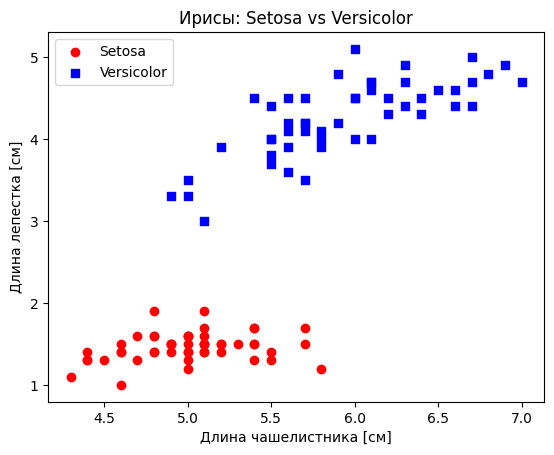

In [8]:
plt.scatter(X[:50, 0], X[:50, 1], color='red', marker='o', label='Setosa')
plt.scatter(X[50:100, 0], X[50:100, 1], color='blue', marker='s', label='Versicolor')
plt.xlabel('Длина чашелистника [см]')
plt.ylabel('Длина лепестка [см]')
plt.legend(loc='upper left')
plt.title('Ирисы: Setosa vs Versicolor')
plt.show()

## Обучение перцептрона

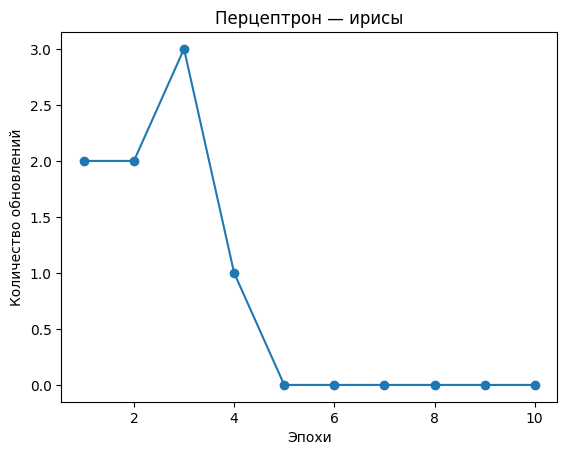

Точность перцептрона: 100.00%


In [9]:
ppn = Perceptron(eta=0.01, n_iter=10)
ppn.fit(X, y)

plt.plot(range(1, len(ppn.errors_) + 1), ppn.errors_, marker='o')
plt.xlabel('Эпохи')
plt.ylabel('Количество обновлений')
plt.title('Перцептрон — ирисы')
plt.show()

accuracy = (ppn.predict(X) == y).mean()
print(f'Точность перцептрона: {accuracy:.2%}')

## Граница решения

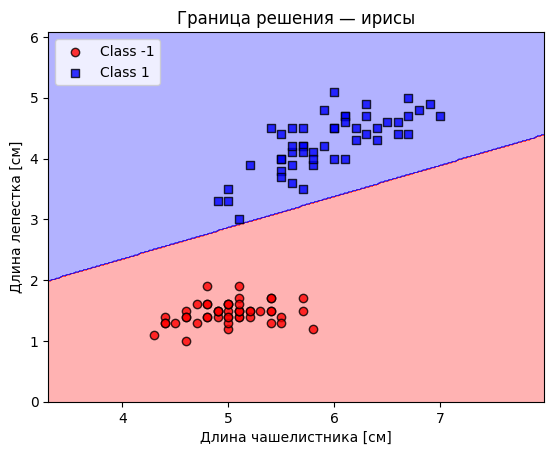

In [10]:
plot_decision_regions(X, y, classifier=ppn)
plt.xlabel('Длина чашелистника [см]')
plt.ylabel('Длина лепестка [см]')
plt.legend(loc='upper left')
plt.title('Граница решения — ирисы')
plt.show()